# FashionMNIST classifier

Run this on Colab. It needs `torch`, which is preinstalled there and not
installed locally.

Kernel selector, top right: `Colab`, then connect.


## Device

In [1]:
import torch, time

device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("Device :", device.upper())

if device == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))
else:
    print()
    print("No GPU attached. Training still runs, just slower.")
    print("Runtime menu, Change runtime type, T4 GPU.")


PyTorch: 2.11.0+cpu
Device : CPU

No GPU attached. Training still runs, just slower.
Runtime menu, Change runtime type, T4 GPU.


## Data

FashionMNIST is 70,000 greyscale 28x28 images across 10 clothing categories.


In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

TRAIN_SUBSET = 6000
TEST_SUBSET = 2000

transform = transforms.ToTensor()

full_train = datasets.FashionMNIST(root="data", train=True, download=True, transform=transform)
full_test = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

train_data = Subset(full_train, range(TRAIN_SUBSET))
test_data = Subset(full_test, range(TEST_SUBSET))

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256)

CLASSES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Boot"]

print(f"Train: {len(train_data):,} of {len(full_train):,}")
print(f"Test : {len(test_data):,} of {len(full_test):,}")
print(f"Shape: {full_train[0][0].shape}")


100%|██████████| 26.4M/26.4M [00:01<00:00, 15.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 236kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.20MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.2MB/s]

Train: 6,000 of 60,000
Test : 2,000 of 10,000
Shape: torch.Size([1, 28, 28])


## Inspect the data before training on it

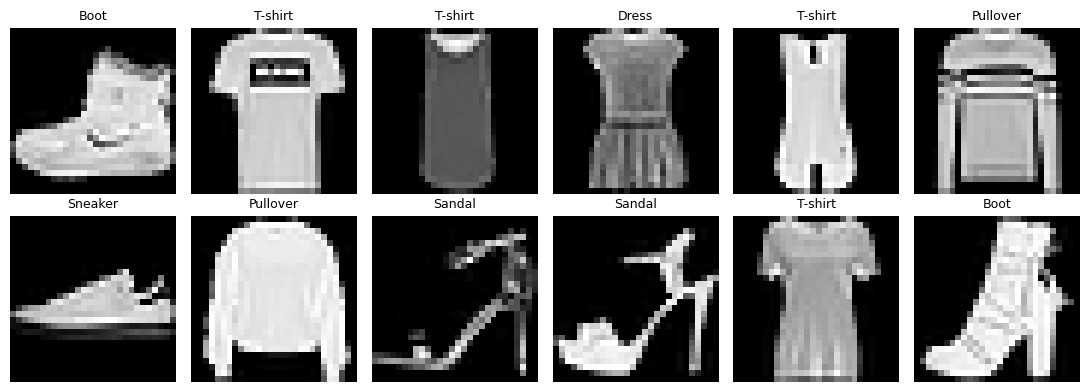

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 6, figsize=(11, 4))
for ax, (img, label) in zip(axes.flat, full_train):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(CLASSES[label], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## Model

Two convolutional blocks, then two linear layers. The convolutions pick up
local structure, pooling halves the resolution each time, and the linear
layers turn the result into ten scores.


In [4]:
import torch.nn as nn

model = nn.Sequential(
    nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128), nn.ReLU(),
    nn.Dropout(0.25),
    nn.Linear(128, 10),
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")
print(f"Device    : {device.upper()}")


Parameters: 421,642
Device    : CPU


## Training

One epoch is one full pass over the training set. Test accuracy is measured
on images the model has not seen.


In [5]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 3
start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        predictions = model(images)
        loss = loss_fn(predictions, labels)
        loss.backward()
        optimizer.step()
        running += loss.item() * images.size(0)

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            guess = model(images).argmax(dim=1)
            correct += (guess == labels).sum().item()
            total += labels.size(0)

    print(f"Epoch {epoch}/{EPOCHS}  loss {running/len(train_data):.4f}  "
          f"test accuracy {100*correct/total:.2f}%")

print(f"\nElapsed: {time.time()-start:.1f} s on {device.upper()}")


Epoch 1/3  loss 1.2315  test accuracy 71.65%
Epoch 2/3  loss 0.6825  test accuracy 78.60%
Epoch 3/3  loss 0.5601  test accuracy 80.25%

Elapsed: 26.0 s on CPU


## Predictions, green correct and red wrong

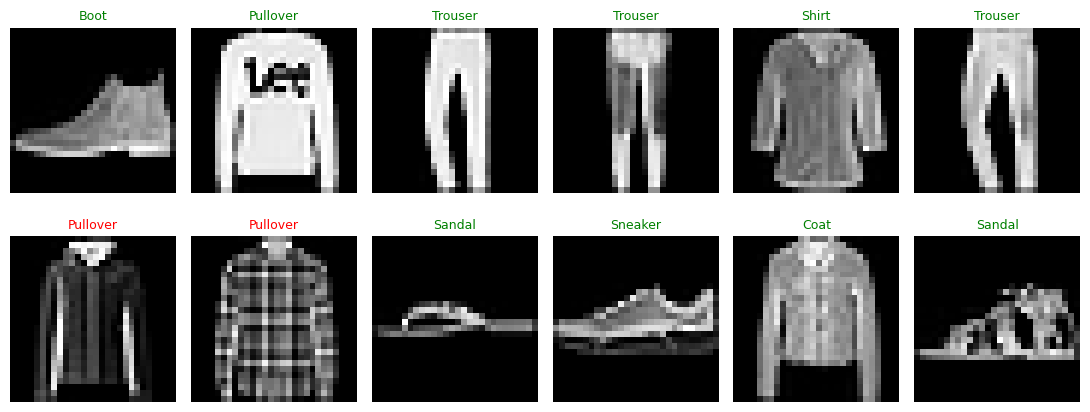

In [6]:
model.eval()
images, labels = next(iter(test_loader))
with torch.no_grad():
    guesses = model(images.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 6, figsize=(11, 4.5))
for ax, img, truth, guess in zip(axes.flat, images, labels, guesses):
    ax.imshow(img.squeeze(), cmap="gray")
    ok = (truth == guess)
    ax.set_title(CLASSES[guess], fontsize=9, color="green" if ok else "red")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Variations worth trying

Raise `EPOCHS` to 10 and watch accuracy plateau. Switch the runtime to CPU
and time the same run against the GPU. Set `lr=1.0` to see divergence.

To keep a trained model past the end of the session:

```python
from google.colab import drive
drive.mount('/content/drive')
torch.save(model.state_dict(), '/content/drive/MyDrive/fashion_model.pt')
```
